In [1]:
# Libraries needed for this analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Load the bottle fill data

data = pd.read_csv("bottle_fills.csv")

# Display the first 5 records

data.head()

,timestamp,fill_amount
0,2024-01-15 08:00:00,12.049671
1,2024-01-15 08:00:30,11.986224
2,2024-01-15 08:01:00,12.064869
3,2024-01-15 08:01:30,12.152453
4,2024-01-15 08:02:00,11.976785


In [3]:
# Check column names

print(data.columns)

# Check size of dataset

print(data.shape)

# Basic information

data.info()

Index(['timestamp', 'fill_amount'], dtype='str')
(1000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    1000 non-null   str    
 1   fill_amount  1000 non-null   float64
dtypes: float64(1), str(1)
memory usage: 15.8 KB


In [16]:
# explore the data
print(data.shape)
print(data.info())
data.describe()
data.describe()

(1000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    1000 non-null   str    
 1   fill_amount  1000 non-null   float64
dtypes: float64(1), str(1)
memory usage: 15.8 KB
None


,fill_amount
count,1000.000000
mean,12.027233
std,0.108352
min,11.611045
25%,11.958052
50%,12.028160
75%,12.091863
max,12.888700


In [5]:
# Extract fill amounts for analysis

fills = data["fill_amount"]

# Quick check
print(fills.head())

0    12.049671
1    11.986224
2    12.064869
3    12.152453
4    11.976785
Name: fill_amount, dtype: float64


In [6]:
# Mean and standard deviation

mean_fill = fills.mean()
std_fill = fills.std()

print("Mean:", mean_fill)
print("Standard Deviation:", std_fill)

Mean: 12.02723333476538
Standard Deviation: 0.1083520719201837


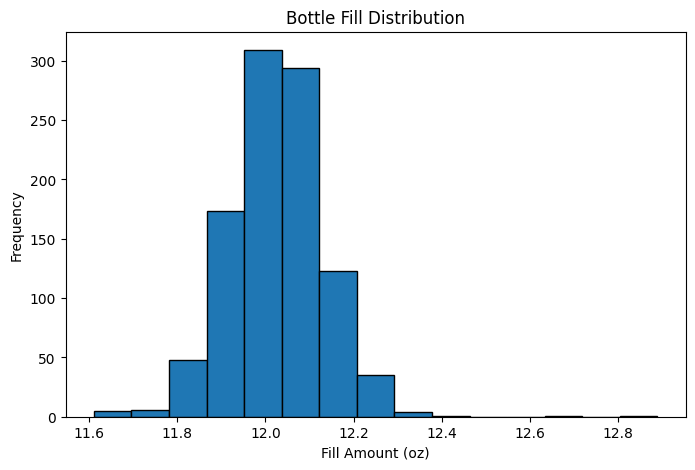

In [7]:
# Visual check for normal distribution

plt.figure(figsize=(8,5))

plt.hist(fills, bins=15, edgecolor="black")

plt.title("Bottle Fill Distribution")
plt.xlabel("Fill Amount (oz)")
plt.ylabel("Frequency")

plt.show()

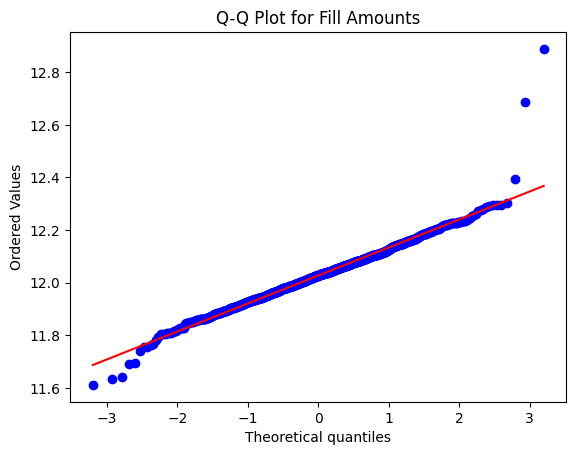

In [8]:
import scipy.stats as stats

# Q-Q plot
stats.probplot(fills, dist="norm", plot=plt)

plt.title("Q-Q Plot for Fill Amounts")
plt.show()

In [9]:
# Test for normality

stat, p = stats.shapiro(fills)

print("Test Statistic:", stat)
print("P-value:", p)

if p > 0.05:
    print("Data is approximately normal")
else:
    print("Data is NOT normal")

Test Statistic: 0.96469814430911
P-value: 7.691129154276352e-15
Data is NOT normal


In [10]:

#Under-filling (less than 11.7 oz)
lower_limit = 11.7

under_prob = stats.norm.cdf(lower_limit, loc=mean_fill, scale=std_fill)

print("Probability of under-filling:", under_prob)

Probability of under-filling: 0.0012634853686131246


In [12]:
#Over-filling (greater than 12.2 oz)
upper_limit = 12.2

over_prob = 1 - stats.norm.cdf(upper_limit, loc=mean_fill, scale=std_fill)

print("Probability of over-filling:", over_prob)

Probability of over-filling: 0.05541278217395029


In [13]:
#Total Rejection Rate
rejection_rate = under_prob + over_prob

print("Total rejection rate:", rejection_rate)

Total rejection rate: 0.05667626754256342


In [14]:
#Acceptable Rate
acceptance_rate = 1 - rejection_rate

print("Acceptance rate:", acceptance_rate)

Acceptance rate: 0.9433237324574366


In [15]:
#Final Decision (5% rule)
if rejection_rate < 0.05:
    print("Process is within acceptable 5% rejection limit.")
else:
    print("Process exceeds 5% rejection limit and needs improvement.")

Process exceeds 5% rejection limit and needs improvement.


11: Interpretation (What your results mean)
1. Under-filling probability
0.00126 ≈ 0.13%
Very low → almost no bottles are underfilled
2. Over-filling probability
0.0554 ≈ 5.54%
This is the main problem area
3. Total rejection rate
0.0567 ≈ 5.67%

Step 12: Final Quality Decision (5% rule)

Company requirement:

Maximum rejection rate = 5%

Your result:

5.67%

Conclusion:

❌ The process does NOT meet the quality requirement

The analysis of the bottle filling process shows that the data is not normally distributed based on the Shapiro-Wilk test. Despite this, probability estimates were computed using the sample mean and standard deviation.

The probability of under-filling (less than 11.7 oz) is approximately 0.0013 (0.13%), while the probability of over-filling (greater than 12.2 oz) is approximately 0.0554 (5.54%). The total rejection rate is 0.0567 (5.67%).

Since the total rejection rate exceeds the company’s maximum allowable limit of 5%, the current filling process is not operating within acceptable quality control limits. The process shows a tendency toward overfilling, which results in product wastage. Therefore, process adjustment is recommended to reduce variability and bring the rejection rate below the acceptable threshold.